In [95]:
import pandas as pd
import numpy as np
import pickle
import statsmodels.api as sm
from scipy.stats import poisson
import seaborn as sns
import matplotlib.pyplot as plt

In [82]:
model_df = pd.read_csv(
    "../data/processed/model_dataset.csv"
)

model_df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_elo,...,match_id,home_form_5,home_avg_goals_5,home_avg_conceded_5,home_avg_goal_diff_5,away_form_5,away_avg_goals_5,away_avg_conceded_5,away_avg_goal_diff_5,goal_difference
0,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,1500.000000,...,1,1.0,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,2
1,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,1490.000000,...,2,1.0,1.000000,2.000000,-1.000000,4.0,2.000000,1.000000,1.000000,1
2,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,1499.424989,...,3,4.0,1.666667,1.333333,0.333333,4.0,1.333333,1.666667,-0.333333,0
3,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,1500.541911,...,4,5.0,1.500000,1.750000,-0.250000,5.0,1.750000,1.500000,0.250000,3
4,1877-03-03,England,Scotland,1,3,Friendly,London,England,False,1489.489284,...,6,5.0,1.400000,1.800000,-0.400000,10.0,2.600000,1.400000,1.200000,-2


In [83]:

features = [
    "elo_diff",

    "home_form_5",
    "away_form_5",

    "home_avg_goals_5",
    "away_avg_goals_5",

    "home_avg_conceded_5",
    "away_avg_conceded_5",

    "home_avg_goal_diff_5",
    "away_avg_goal_diff_5"
]

In [44]:
# variables predictivas / explicativas
X_home = model_df[features]
# variable objetico
y_home = model_df["home_score"]
# agrego una constante para el intercepto.
X_home = sm.add_constant(
    X_home
)

In [45]:
# Entrena el modelo Poisson de goles locales.
home_model = sm.GLM(
    y_home,
    X_home,
    family=sm.families.Poisson()
)

home_results = home_model.fit()

In [46]:
print(
    home_results.summary()
)

                 Generalized Linear Model Regression Results                  
Dep. Variable:             home_score   No. Observations:                22924
Model:                            GLM   Df Residuals:                    22916
Model Family:                 Poisson   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -38701.
Date:                Thu, 25 Jun 2026   Deviance:                       31334.
Time:                        23:03:33   Pearson chi2:                 2.96e+04
No. Iterations:                     5   Pseudo R-squ. (CS):             0.2907
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.1576 

In [84]:
# el visitante es el protagonista.
model_df["away_elo_diff"] = (
    model_df["away_elo"]
    - model_df["home_elo"]
)

In [85]:
# Construye las variables del modelo visitante.
away_features = [
    "away_elo_diff",

    "away_form_5",
    "home_form_5",

    "away_avg_goals_5",
    "home_avg_goals_5",

    "away_avg_conceded_5",
    "home_avg_conceded_5",

    "away_avg_goal_diff_5",
    "home_avg_goal_diff_5"
]

In [49]:
X_away = model_df[
    away_features
]

y_away = model_df[
    "away_score"
]

X_away = sm.add_constant(
    X_away
)

In [50]:
# Entrena el segundo modelo.
away_model = sm.GLM(
    y_away,
    X_away,
    family=sm.families.Poisson()
)

away_results = away_model.fit()

In [51]:
print(
    away_results.summary()
)

                 Generalized Linear Model Regression Results                  
Dep. Variable:             away_score   No. Observations:                22924
Model:                            GLM   Df Residuals:                    22916
Model Family:                 Poisson   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -32878.
Date:                Thu, 25 Jun 2026   Deviance:                       29657.
Time:                        23:03:33   Pearson chi2:                 2.81e+04
No. Iterations:                     6   Pseudo R-squ. (CS):             0.2381
Covariance Type:            nonrobust                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -0.2589 

In [86]:

##    "Modelo Local entrenado"


##    "Modelo Visitante entrenado"


In [53]:
# obtener el estado actual de cada selección.
latest_matches = model_df.sort_values(
    "date"
)

In [87]:
# obtiene el ultimo partido que jugo cada selección como local.
team_features = (
    latest_matches
    .sort_values("date")
    .groupby("home_team")
    .last()
)

In [88]:
# estado actual de cada selección
team_features.head()

,date,away_team,home_score,away_score,tournament,city,country,neutral,home_elo,away_elo,...,home_form_5,home_avg_goals_5,home_avg_conceded_5,home_avg_goal_diff_5,away_form_5,away_avg_goals_5,away_avg_conceded_5,away_avg_goal_diff_5,goal_difference,away_elo_diff
home_team,,,,,,,,,,,,,,,,,,,,,
Abkhazia,2016-05-21,Donetsk PR,0,0,Friendly,Sukhumi,Georgia,False,1525.609995,1491.021519,...,8.0,1.0,0.8,0.2,3.0,1.666667,1.666667,0.0,0,-34.588476
Afghanistan,2026-06-10,Pakistan,0,2,Diamond Jubilee International Football Tournament,Malé,Maldives,True,1285.117095,1179.386710,...,5.0,0.4,0.8,-0.4,8.0,1.200000,1.200000,0.0,-2,-105.730385
Albania,2024-06-24,Spain,0,1,UEFA Euro,Düsseldorf,Germany,True,1577.981714,1932.110736,...,7.0,1.8,1.2,0.6,13.0,3.400000,0.800000,2.6,-1,354.129022
Alderney,2022-04-23,Guernsey,0,2,Muratti Vase,Alderney,Alderney,False,1184.252971,1687.554859,...,3.0,1.2,3.8,-2.6,10.0,3.000000,1.000000,2.0,-2,503.301888
Algeria,2026-01-10,Nigeria,0,2,African Cup of Nations,Marrakesh,Morocco,True,1777.782347,1682.292243,...,13.0,1.8,0.4,1.4,13.0,2.600000,1.000000,1.6,-2,-95.490104


In [57]:
# estado actual de Argentina
team_features.loc["Argentina"]

date                       2024-07-14
away_team                    Colombia
home_score                          1
away_score                          0
tournament               Copa América
city                    Miami Gardens
country                 United States
neutral                          True
home_elo                  1995.626709
away_elo                   1927.83359
elo_diff                    67.793119
match_id                        47471
home_form_5                      13.0
home_avg_goals_5                  1.6
home_avg_conceded_5               0.2
home_avg_goal_diff_5              1.4
away_form_5                      13.0
away_avg_goals_5                  2.4
away_avg_conceded_5               0.4
away_avg_goal_diff_5              2.0
goal_difference                     1
away_elo_diff              -67.793119
Name: Argentina, dtype: object

In [59]:
# estado actual de Brazil
team_features.loc["Brazil"]

date                        2026-05-31
away_team                       Panama
home_score                           6
away_score                           2
tournament                    Friendly
city                    Rio de Janeiro
country                         Brazil
neutral                          False
home_elo                   1908.866981
away_elo                   1697.442496
elo_diff                    211.424485
match_id                         49276
home_form_5                        7.0
home_avg_goals_5                   1.8
home_avg_conceded_5                1.4
home_avg_goal_diff_5               0.4
away_form_5                        8.0
away_avg_goals_5                   1.4
away_avg_conceded_5                0.8
away_avg_goal_diff_5               0.6
goal_difference                      4
away_elo_diff              -211.424485
Name: Brazil, dtype: object

In [60]:
team_strength = team_features[
    [
        "home_elo",
        "home_form_5",
        "home_avg_goals_5",
        "home_avg_conceded_5",
        "home_avg_goal_diff_5"
    ]
].copy()

In [91]:
# construye el dataset que usará el simulador con ELO, forma y promedios
team_strength.columns = [
    "elo",
    "form_5",
    "avg_goals_5",
    "avg_conceded_5",
    "avg_goal_diff_5"
]

In [94]:
def predict_match(home_team, away_team):

    # Obtiene las estadísticas actuales de ambos equipos.
    home = team_strength.loc[home_team]
    away = team_strength.loc[away_team]

    # Calcula ELO diferencia
    elo_diff = (
        home["elo"]
        - away["elo"]
    )

    # Construye el DataFrame local
    home_data = pd.DataFrame({
        "const": [1],
        "elo_diff": [elo_diff],

        "home_form_5": [home["form_5"]],
        "away_form_5": [away["form_5"]],

        "home_avg_goals_5": [home["avg_goals_5"]],
        "away_avg_goals_5": [away["avg_goals_5"]],

        "home_avg_conceded_5": [home["avg_conceded_5"]],
        "away_avg_conceded_5": [away["avg_conceded_5"]],

        "home_avg_goal_diff_5": [home["avg_goal_diff_5"]],
        "away_avg_goal_diff_5": [away["avg_goal_diff_5"]]
    })

    # Predice
    lambda_home = home_results.predict(
        home_data
    )[0]

    # Construye el DataFrame Visitante
    away_data = pd.DataFrame({
        "const": [1],

        "away_elo_diff": [-elo_diff],

        "away_form_5": [away["form_5"]],
        "home_form_5": [home["form_5"]],

        "away_avg_goals_5": [away["avg_goals_5"]],
        "home_avg_goals_5": [home["avg_goals_5"]],

        "away_avg_conceded_5": [away["avg_conceded_5"]],
        "home_avg_conceded_5": [home["avg_conceded_5"]],

        "away_avg_goal_diff_5": [away["avg_goal_diff_5"]],
        "home_avg_goal_diff_5": [home["avg_goal_diff_5"]]
    })

    # Predice
    lambda_away = away_results.predict(
        away_data
    )[0]

    #N10
    return {
        "home_team": home_team,
        "away_team": away_team,
        "lambda_home": float(lambda_home),
        "lambda_away": float(lambda_away)
    }

In [64]:
predict_match(
    "Argentina",
    "Brazil"
)

{'home_team': 'Argentina',
 'away_team': 'Brazil',
 'lambda_home': 1.7873419862278517,
 'lambda_away': 0.7642810649847928}

In [96]:
# Funcion que recibe local y visitante -> calcula probabilidad de: gana local, gana visitante. empate
def match_probabilities(
    home_team,
    away_team,
    max_goals=10
):

    prediction = predict_match(
        home_team,
        away_team
    )

    lambda_home = prediction["lambda_home"]
    lambda_away = prediction["lambda_away"]

    home_win = 0
    draw = 0
    away_win = 0

    for hg in range(max_goals + 1):
        for ag in range(max_goals + 1):

            p = (
                poisson.pmf(hg, lambda_home)
                *
                poisson.pmf(ag, lambda_away)
            )

            if hg > ag:
                home_win += p

            elif hg == ag:
                draw += p

            else:
                away_win += p

    return {
        "home_team": home_team,
        "away_team": away_team,
        "home_win": home_win,
        "draw": draw,
        "away_win": away_win
    }

In [68]:
prediction = predict_match(
    "Argentina",
    "Brazil"
)

lambda_home = prediction["lambda_home"]
lambda_away = prediction["lambda_away"]

In [69]:
max_goals = 6

score_matrix = np.zeros(
    (
        max_goals + 1,
        max_goals + 1
    )
)

In [70]:
for hg in range(max_goals + 1):

    for ag in range(max_goals + 1):

        score_matrix[hg, ag] = (
            poisson.pmf(
                hg,
                lambda_home
            )
            *
            poisson.pmf(
                ag,
                lambda_away
            )
        )

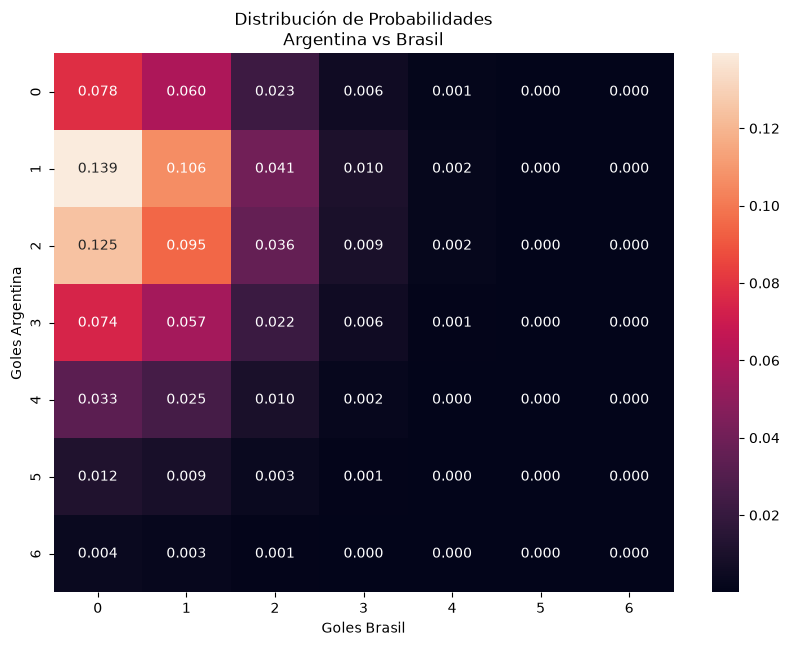

In [71]:
plt.figure(figsize=(10,7))

sns.heatmap(
    score_matrix,
    annot=True,
    fmt=".3f"
)

plt.xlabel("Goles Brasil")
plt.ylabel("Goles Argentina")

plt.title(
    "Distribución de Probabilidades\nArgentina vs Brasil"
)

plt.show()

In [73]:
team_strength.to_csv(
    "../data/processed/team_strength.csv"
)

In [75]:
with open(
    "../models/home_poisson.pkl",
    "wb"
) as f:

    pickle.dump(
        home_results,
        f
    )

In [76]:
with open(
    "../models/away_poisson.pkl",
    "wb"
) as f:

    pickle.dump(
        away_results,
        f
    )